In [2]:
import csv
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

In [3]:
# get data in 1990s
df = pd.read_csv('thesis__data_res.csv', usecols=['YEAR', 'BMICALC', 'WEIGHT', 'SEX'])

# remove samples without valid bmi
df = df[(df['BMICALC']<900) & (df['BMICALC']>0)]
# select years
df_1990s = df[(df['YEAR']==1990)|(df['YEAR']==1991)]
# remove sampled that wond not value bmi if samples in 2010s
df_1990s = df_1990s[((df_1990s['SEX']==2) & (df_1990s['WEIGHT']>100) & (df_1990s['WEIGHT']<274)) |
                    ((df_1990s['SEX']==1) & (df_1990s['WEIGHT']>126) & (df_1990s['WEIGHT']<299)) ] 
# top and bottom code
df_1990s['BMICALC'] = df_1990s['BMICALC'].clip(upper=50, lower=15)

# create list of bmi values
df_1990s_bmi = list(df_1990s['BMICALC'])

In [5]:
# get data from 2010s
df_train = pd.read_csv('df_train.csv')
df_test = pd.read_csv('df_test.csv')
# concatinate
df_final = pd.concat([df_train, df_test], ignore_index=True)

# top code
df_final['BMICALC'] = df_final['BMICALC'].clip(upper=50, lower=15)

# get list of values
df_2010s_bmi = list(df_final['BMICALC'])

In [6]:
def quantile_match_transform(data_2010s, data_1990s, num_quantiles=100):

    # grid (from 0 to 100%)
    quantiles = np.linspace(0, 1, num_quantiles)

    # empirical quantiles of each distribution
    q_2010s = np.quantile(data_2010s, quantiles)
    q_1990s = np.quantile(data_1990s, quantiles)

    # interpolation function
    def T(x):
        return np.interp(x, q_2010s, q_1990s)

    return T

# get T
T = quantile_match_transform(df_2010s_bmi, df_1990s_bmi)

x_vals = np.linspace(np.min(df_2010s_bmi), np.max(df_2010s_bmi), 100)
y_vals = T(x_vals)

# save to open in new notebook and ajdsut bmi on other dataset based on this function
np.savez('x_y_vals.npz', x_vals=x_vals, y_vals=y_vals)

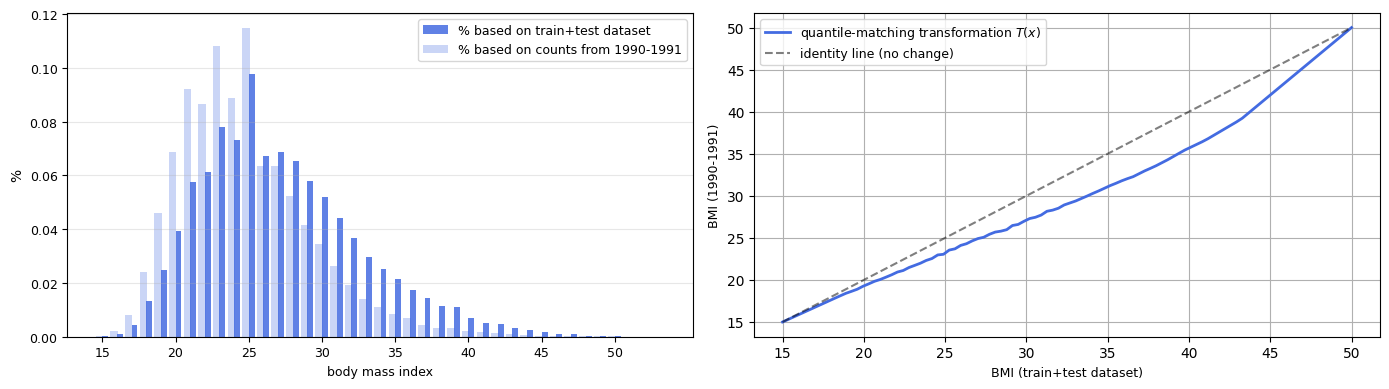

In [7]:
# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- BMI distribution comparison plot ---
# define common bins
bins = np.arange(15, 55, 1)
bin_centers = bins[:-1] 
# histogram counts for left plots
counts_2010s, _ = np.histogram(df_2010s_bmi, bins=bins)
counts_1990s, _ = np.histogram(df_1990s_bmi, bins=bins)
# normalize to proportions
counts_2010s = counts_2010s / counts_2010s.sum()
counts_1990s = counts_1990s / counts_1990s.sum()
axes[0].bar(bin_centers + 0.2, counts_2010s, width=0.4 ,
            label='% based on train+test dataset', color='royalblue', alpha=0.84)
axes[0].bar(bin_centers - 0.2, counts_1990s, width=0.5,
            label='% based on counts from 1990-1991', color='royalblue', alpha=0.28)

axes[0].set_xlabel('body mass index', fontsize=9)
axes[0].set_ylabel('%')
axes[0].set_xticks(np.arange(15, 55, 5))
axes[0].tick_params(axis='x', labelrotation=0, labelsize=9)
axes[0].tick_params(axis='y', labelsize=9)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)


# --- plot T(x) ---
axes[1].plot(x_vals, y_vals, color='royalblue', alpha=0.99, lw=2, label='quantile-matching transformation $T(x)$')
axes[1].plot(x_vals, x_vals, 'k--', alpha=0.5, label='identity line (no change)')
axes[1].set_xlabel('BMI (train+test dataset)', fontsize=9)
axes[1].set_ylabel('BMI (1990-1991)', fontsize=9)
axes[1].legend(fontsize=9)
axes[1].grid(True)


plt.tight_layout()
plt.savefig('bmi16_side_by_side.png', format='png', dpi=300, bbox_inches='tight')
plt.show()